## **Demographic Trends and Figures for ICE arrests (2011-12, 2014-25)**
We unfortunately do not have data for 2013, but we can still observe trends over the four presidential administrations (and five terms in office) that span this dataset: 
- Obama Administration (Oct 2011-2017, including the tail of his first term & all of his second)
- First Trump Administration (2017-2020)
- Biden Administration (2020-2024)
- Current Trump Administration (2024-Oct 2025)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, datetime

input_path = "/home/betel/Desktop/Spring '26/Notes/ICE/Datasets/"
input_name = "Arrests 2011-2025.csv"

#catch warnings on the read because some columns are mixed type (include null values)
with warnings.catch_warnings(): 
    warnings.simplefilter("ignore")
    arrests = pd.read_csv(input_path + input_name).drop(columns="Unnamed: 0")
    
    #minor normalization -> datetime objects get saved as strings, so this re-converts
    arrests["Apprehension Date Time"] = pd.to_datetime(arrests["Apprehension Date Time"], format='ISO8601')
    arrests["Apprehension Month"] = arrests["Apprehension Date Time"].dt.to_period('M')
    
    #aggregated arrests variable by month, as this analysis is frequency-centric
    aggregated_arrests = arrests.groupby(by="Apprehension Month")

In [2]:
#helper func to format our graphs from here on out. Displays presedential inaugurations
def plot_administrations(xlabel, ylabel, title):
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis='y')

    # these vertical lines show the change in administrations
    plt.axvline(x = 564.645, color = 'r', label = 'Trump inaugurated', ls = "--")
    plt.axvline(x = 612.645, color = 'k', label = 'Biden inaugurated', ls = ":")
    plt.axvline(x = 660.625, color = 'r', ls = "--")

    # legend is made smaller so graph is more readable
    plt.legend(fontsize = "small", framealpha = 0.6)

# Figures

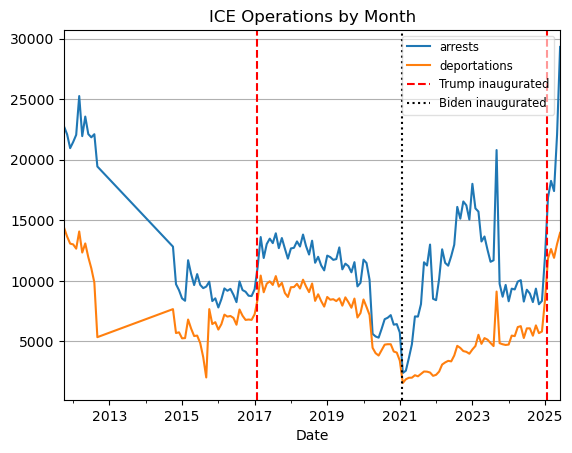

In [3]:
#quick & easy variables
arrests_agg = aggregated_arrests.size()
deportations_agg = aggregated_arrests["Deported"].sum()

#combine series, drop last month due to incomplete data
arrests_monthly = pd.concat([arrests_agg, deportations_agg], axis=1)[:-1]
arrests_monthly.columns = ["arrests", "deportations"]

# plots count of arrests per week in a line plot
arrests_monthly.plot()
plot_administrations('Date', '', 'ICE Operations by Month')

### Citizenship Country
Early on in going through the data, we noticed that the majority of people arrested were citizens of Mexico. This is expected, due to the geographic & socioeconomic position of Mexico to the USA. Variance between administrations may reflect differently in minor on foreign policy relating to immigration & trade, as well more majorly as on domestic policy relating to racial profiling.

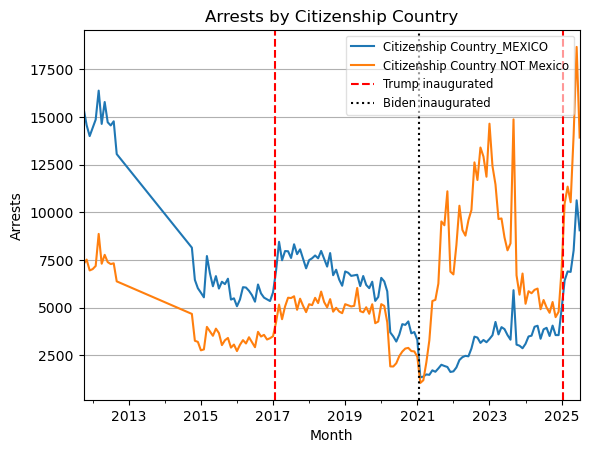

In [4]:
# separates out arrests by citizenship country and takes out any data that does not have a value for citizenship country
arr_country_dummies = pd.get_dummies(arrests[arrests["Citizenship Country"].notna()], columns = ["Citizenship Country"])

# creates a column containing all arrests of people who were not from Mexico
arr_country_dummies["Citizenship Country NOT Mexico"] = ~arr_country_dummies["Citizenship Country_MEXICO"]

# groups data by month so that the graph is readable
arr_country_dummies.groupby(by="Apprehension Month")\
    [["Citizenship Country_MEXICO", "Citizenship Country NOT Mexico"]].sum().plot()

#formatting
plot_administrations('Month', 'Arrests', 'Arrests by Citizenship Country')
plt.show()

Alt text: Line graph with the title "Arrests per month by citizenship country (Oct 2011 to July 2025)". The y-axis is arrests (per month) and it ranges from 0 to about 20000. The x-axis is date and it ranges from just before 2012 to about midway through 2025. There are three vertical lines on the graph: a red dashed line labeled "Trump inauguration (first)" which is located shortly after 2017, a black dotted line labeled "Biden inauguration" located just after 2020, and a pink dashed and dotted line labeled "Trump inauguration (second)" which is located just after 2025. There are two horizontal lines: a blue line containing the arrests per month data of Mexican citizens and an orange line containing the arrests per month data of non-Mexican citizens. In the period before the first Trump inauguration, the Mexican citizen arrests (per month) begins at around 15000 until October 2012. The non-Mexican citizen arrests are about 7500 during this period. Then there is no arrests data until October 2014. From October 2014 till the first Trump inauguration, the Mexican citizen arrests per month quantity hovers around 6000 and the non-Mexican citizen arrests hover around 3000 per month. After the first Trump inauguration, the Mexican citizen arrests per month increase to around 7500 and slowly declines to about 6000 until 2020, when they sharply decline to about 3000 until Biden's administration. During this time, the non-Mexican citizen arrests hover around 5000 per month until 2020, when they decline to 2500 until Biden's administration. Here, the curves dramatically diverge. During Biden's term the Mexican citizen arrests start at about 1200 per month and slowly increase to about 3000 per month. The non-Mexican citizen arrests increase to about 15000 in 2023 and decrease back to 5000 at the end of Biden's term. At the start of Trump's second term, the non-Mexican citizen arrests sharply increase to about 11000 and then 18000 arrests per month. The Mexican citizen arrests increase from about 5000 to 10000 arrests per month.

**This isn't as obvious as the arrests data.** Most of the data appears to be roughly following the general trend of the arrests data. The most surprising thing is during Biden's term when the Mexican citizen arrest data does not peak in the same way as the rest of the data. Despite this graph, we still know that after 2020, Mexican citizens were still a plurality of the ICE arrests. This peak of non-Mexican arrests might be a reflection of policy changes during the Biden administration

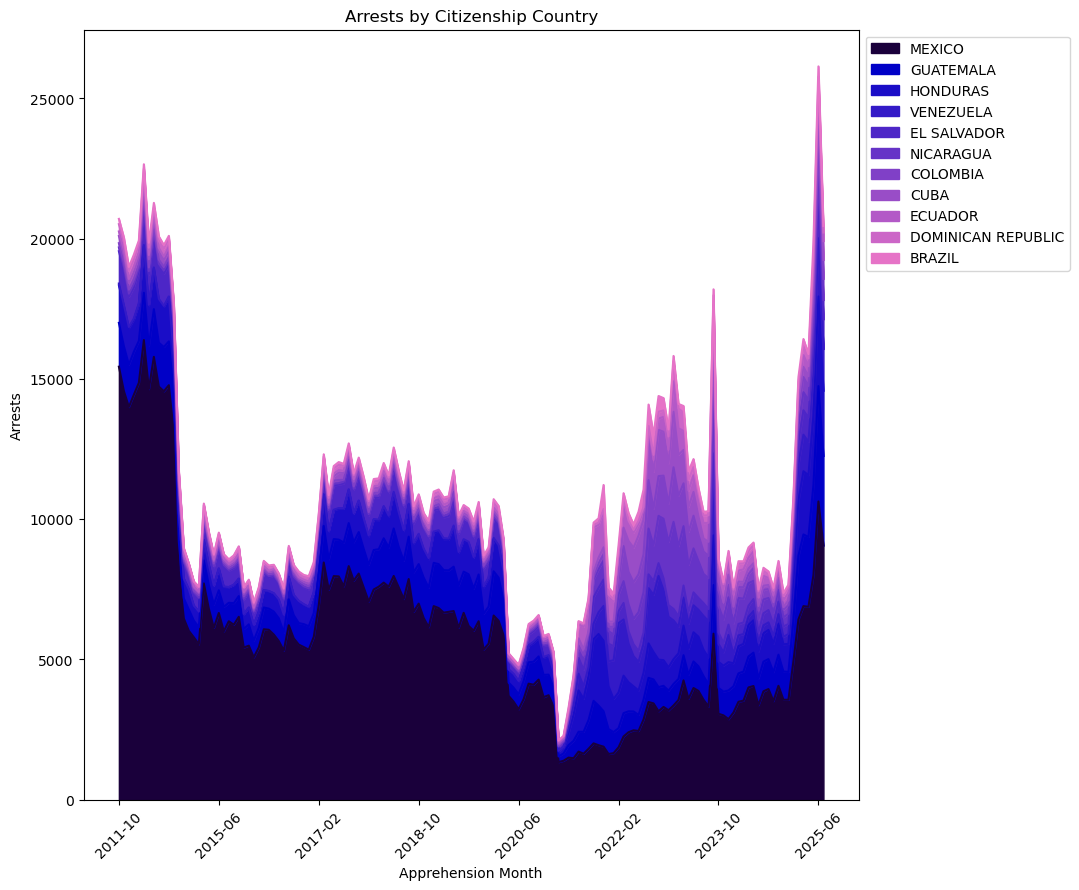

In [5]:
from itertools import cycle, islice

countries_monthly = arrests[['Citizenship Country','Apprehension Month']].value_counts().reset_index()\
                   .pivot(index='Citizenship Country',columns='Apprehension Month',values='count').fillna(0)

#thank you eli on stackoverflow for this pretty function!
my_colors = [(.1, 0,.23)]+[(x/10.0, x/20.0, 0.78) for x in range(len(countries_monthly.T))] # <-- gradient

countries_monthly["Post 2020"] = countries_monthly.iloc[:, -5:].sum(axis=1)
countries_monthly.sort_values(by="Post 2020", ascending=False).drop("Post 2020", axis=1).head(11).T\
                .plot.area(figsize=(10,10), color=my_colors, title="Arrests by Citizenship Country", ylabel="Arrests", rot=45)\
                .legend(bbox_to_anchor=(1, 1), loc='upper left');#, reverse=True) <-- upgrade to matplotlib 3.7

### State
Next, we wanted to investigate the arrests throughout the states. Texas unsurprisingly comes out on top with 220,000 arrests, but there are almost three times as many arrests from Texas, than from the next highest state, California with 78,168 arrests. It is important to note here that state data only started being collected in October of 2015, so this does not include data collected prior to then.

In [6]:
arrests["Apprehension State"].value_counts().head(5)

Apprehension State
TEXAS         221651
CALIFORNIA     78168
FLORIDA        64424
NEW YORK       50289
GEORGIA        46856
Name: count, dtype: int64

First we looked at the arrests per month in Texas and not in Texas.

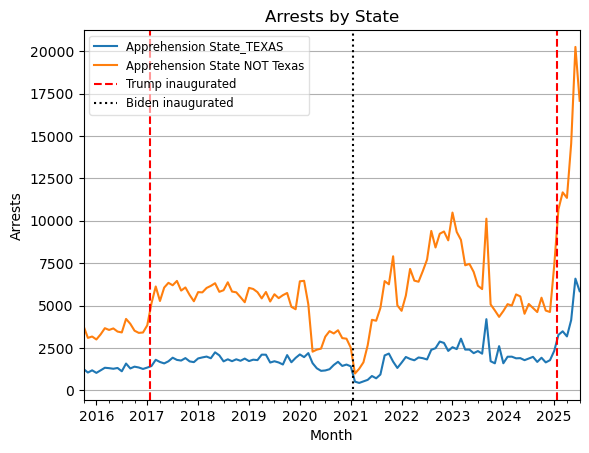

In [7]:
# separates out arrests by apperehension state and takes out any data that does not have a value for apprehension state
arr_state_dummies = pd.get_dummies(arrests[arrests["Apprehension State"].notna()], columns = ["Apprehension State"])

# creates a column containing all arrests of people who were not from Texas
arr_state_dummies["Apprehension State NOT Texas"] = ~arr_state_dummies["Apprehension State_TEXAS"]

# groups data by month so that the graph is readable
arr_state_dummies.groupby(by="Apprehension Month")\
    [["Apprehension State_TEXAS", "Apprehension State NOT Texas"]].sum().plot()

plot_administrations("Month", "Arrests", "Arrests by State")
plt.show()

Alt text: Line graph with the title "Arrests per month by state (Oct 24, 2015 to July 2025)". The y-axis is arrests (per month) and it ranges from 0 to about 20000. The x-axis is date and it ranges from just before 2016 to about midway through 2025. There are three vertical lines on the graph: a red dashed line labeled "Trump inauguration (first)" which is located shortly after 2017, a black dotted line labeled "Biden inauguration" located just after 2020, and a pink dashed and dotted line labeled "Trump inauguration (second)" which is located just after 2025. There are two horizontal lines: a blue line containing the arrests per month data in Texas and an orange line containing the arrests per month data not in Texas. In the period before the first Trump inauguration, the Texas arrests (per month) begins at around 1250 and slowly increases until the first Trump administration. The non-Texas arrests are about 3000 during this period. After the first Trump inauguration, the Texas arrests per month stay around 2200 per month. During this time, the non-Texas arrests hover around 5500 per month until 2020, when they decline to 2500 until Biden's administration. Here, the curves diverge. During Biden's term the Texas arrests start at about 500 per month and slowly increase to about 2200 per month (with a small peak in 2023). The non-Texas arrests increase to about 10000 in 2023 and decrease back to 5000 at the end of Biden's term. At the start of Trump's second term, the non-Texas arrests sharply increase to about 11000 and then 20000 arrests per month. The Texas arrests increase from about 2500 to 6250 arrests per month.

**This appears to just be a reflection of the arrests data.** There do not appear to be any strange results here. Texas arrests do not decrease much during the height of COVID, which is likely due to the minimal lockdown policies in Texas at the time. It is interesting to see how much of the data is just from Texas, though.

We then wondered what the top five states (Texas, California, Florida, New York, and Georgia) look like here.

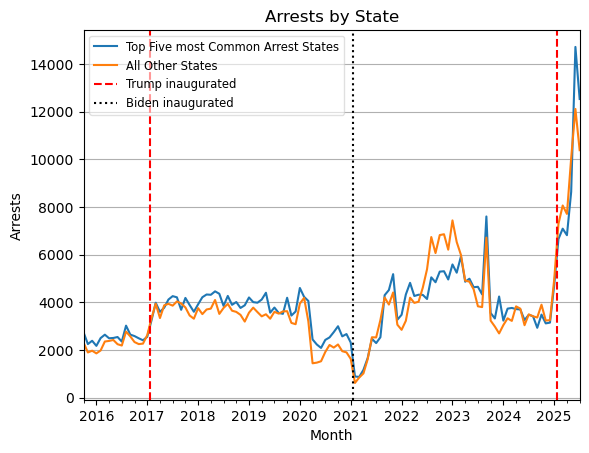

In [8]:
# creates a column containing all arrests of people who were not from Texas, California, Florida, New York, and Georgia
arr_state_dummies["Top Five most Common Arrest States"] = \
    arr_state_dummies["Apprehension State_TEXAS"] + \
    arr_state_dummies["Apprehension State_CALIFORNIA"] + \
    arr_state_dummies["Apprehension State_FLORIDA"] + \
    arr_state_dummies["Apprehension State_NEW YORK"] + \
    arr_state_dummies["Apprehension State_GEORGIA"]
arr_state_dummies["All Other States"] = ~arr_state_dummies["Top Five most Common Arrest States"]

# groups data by month so that the graph is readable
arr_state_dummies.groupby(by="Apprehension Month")\
    [["Top Five most Common Arrest States", "All Other States"]].sum().plot()

plot_administrations("Month", "Arrests", "Arrests by State")

plt.show()

Alt text: Line graph with the title "Arrests per month by state (Oct 24, 2015 to July 2025)". The y-axis is arrests (per month) and it ranges from 0 to about 15000. The x-axis is date and it ranges from just before 2016 to about midway through 2025. There are three vertical lines on the graph: a red dashed line labeled "Trump inauguration (first)" which is located shortly after 2017, a black dotted line labeled "Biden inauguration" located just after 2020, and a pink dashed and dotted line labeled "Trump inauguration (second)" which is located just after 2025. There are two horizontal lines: a blue line containing the arrests per month data in Texas, California, Florida, New York, and Georgia and an orange line containing the arrests per month data not in these states. Both of these lines are essentially at the same values for the whole graph, so they will be described at the same time. In the period before the first Trump inauguration, the arrests (per month) hovers at around 2500 per month until the first Trump administration. Then, the arrests per month stay around 4000 per month until they sharply decrease in 2020 to around 2000 per month. During the Biden administration, the arrests go from aroung 1250 per month to a peak of 6000 in 2023 and then they decrease to 3500 at the end of his term. At the start of Trump's second term, the arrests sharply increase to about 7500 and then 13000 arrests per month.

This graph just shows that the combination of arrest data from the top five states (Texas, California, Florida, New York, and Georgia) is about equivalent to the arrest data from the entire rest of the dataset. There is not an administration correlation here.

### Gender
Now, on to gender! Due to the relatively small amount of data of "unknown" gender (1337 unknown vs. 226,969 women), it was not included in the graph. We wonder what the one entry of gender of "IIDS ETL NULL" means. What does it mean to have that as your gender? Can 

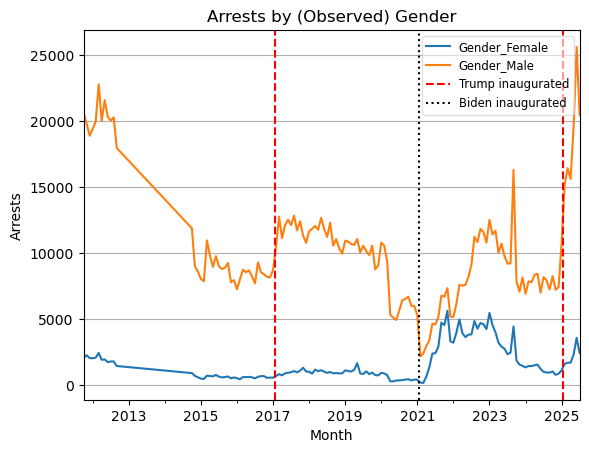

In [9]:
# separates out arrests by gender
arr_gender_dummies = pd.get_dummies(arrests, columns = ["Gender"])

# groups data by month so that the graph is readable
arr_gender_dummies.groupby(by="Apprehension Month")[["Gender_Female", "Gender_Male"]].sum().plot()

plot_administrations("Month", "Arrests", "Arrests by (Observed) Gender")

plt.show()

Alt text: Line graph with the title "Arrests per month by (observed) gender (Oct 2011 to July 2025)". The y-axis is arrests (per month) and it ranges from 0 to about 25500. The x-axis is date and it ranges from just before 2012 to about midway through 2025. There are three vertical lines on the graph: a red dashed line labeled "Trump inauguration (first)" which is located shortly after 2017, a black dotted line labeled "Biden inauguration" located just after 2020, and a pink dashed and dotted line labeled "Trump inauguration (second)" which is located just after 2025. There are two horizontal lines: a blue line containing the arrests per month data in of people labeled as "Female" and an orange line containing the arrests per month data of those labeled "Male". From October 2011 till October 2012, the Male line hovers aroung 20200 arrests per month and the Female line hovers around 2000. Then from October 2012 to October 2014 there is no data. From October 2015 until the first Trump inauguration, the Male arrests (per month) hovers around 9000 and the Female arrests stay constant at around 700 per month. During the first Trump term, the Male arrests per month start around 11500 and slowly decrease to 10000 at the start of 2020. Then they sharply decline to 5000 until the begining of the Biden administration. During Trump's term, the Female arrests stay at about 1000 per month and then decrease down to 500 in 2020. During Biden's term the Male arrests start at about 2500 per month and peak at about 12000 per month at the start of 2023 and then decrease to about 7500 in 2024. The Female arrests also peak in Biden's term. They go from about 50 per month to 5000 per month at the start of 2023 and then they decrease to about 1000 per month at the end of his term. In Trump's second term, the Male arrests sharply increase to 12500 and then 25000 arrests per month and the Female arrests increase to 1500 and then peak at 3700 per month.

This graph appears to reflect the larger arrests data, although the overall trend is largely absent in the Female data (until Biden's term).